Lutas REALIZADO: 3483 | Período: 2002-2026
Decisivas: 3431 | Title fights: 240

[Q1] Spearman (year vs duration, non-title): rho=0.106, p=4.61e-09, n=3052

[Q2] Qui-quadrado pre/post-2020: chi2=49.65, p=9.478e-11, V de Cramer=0.120, n=3429

[Q3] Classes analisadas: 10
                      n    mean   std  median
weight_class_clean                           
Heavyweight          49  188.53  6.60  187.96
Light Heavyweight   120  188.36  6.33  187.96
Middleweight        345  185.27  4.74  185.42
Welterweight        644  182.50  4.93  182.88
Lightweight         660  178.81  5.27  177.80
Catchweight         380  176.96  7.18  177.80
Featherweight       643  174.94  4.50  175.26
Bantamweight        533  171.07  4.95  170.18
Flyweight           345  167.49  4.20  167.64
Strawweight          33  162.02  3.63  160.02

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
     Welterweight 227    0.5947  0.5298   0.6565   0.0052      0.04

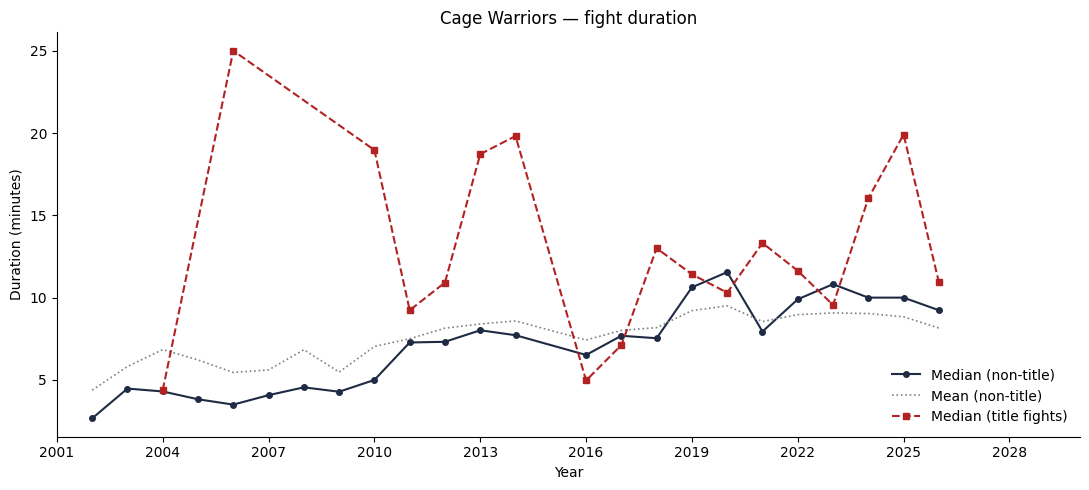

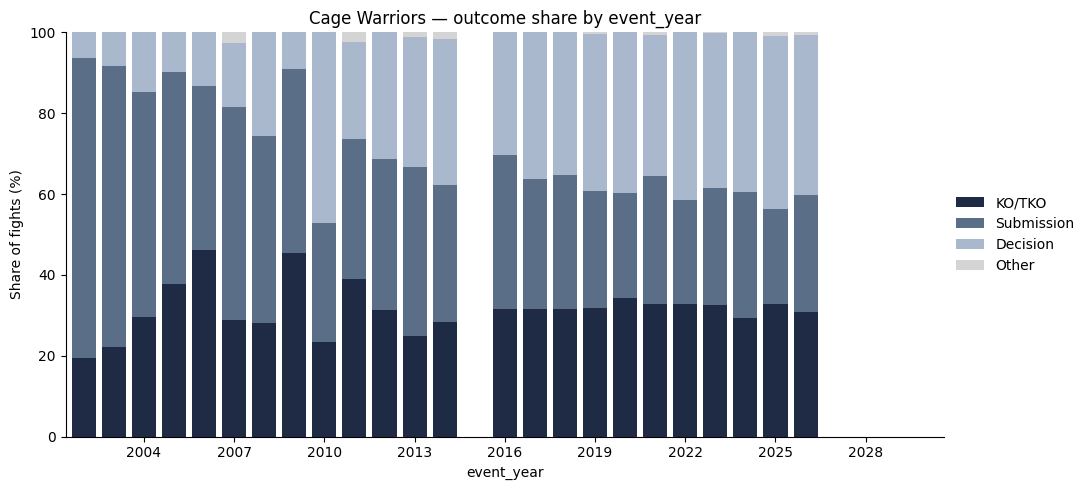

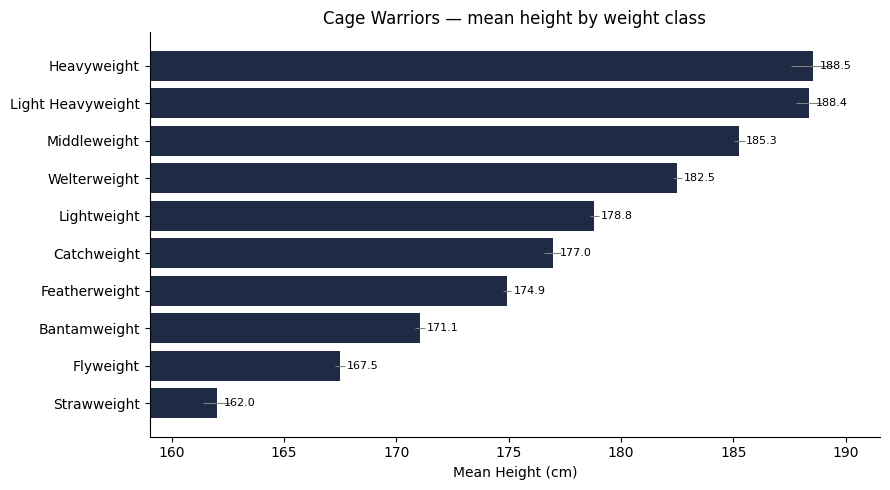

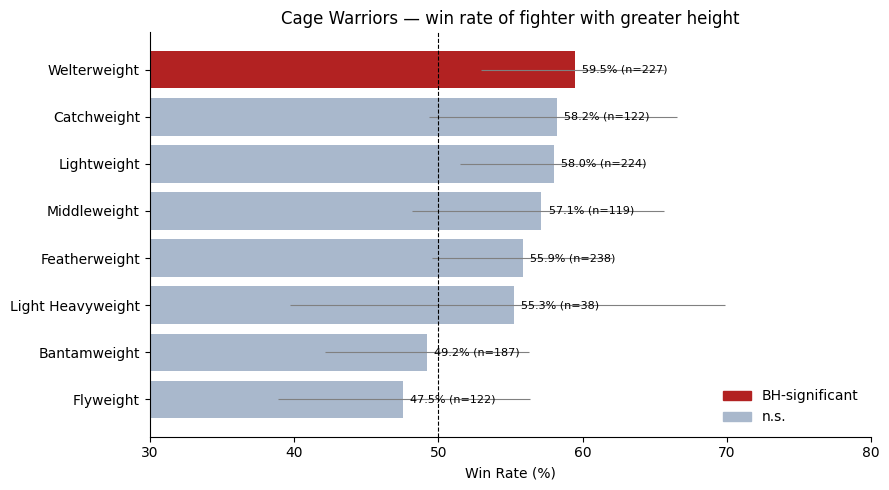

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/cage-warriors-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_cagewarriors.csv'
JSON_PATH = f'{DATA_DIR}/cagewarriors_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_cagewarriors():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            r = int(row['round_num'])
            if r < 1:
                return np.nan
            return (r - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('Cage Warriors — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('Cage Warriors — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('Cage Warriors — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Cage Warriors — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_cagewarriors()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_cagewarriors_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_cagewarriors_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_cagewarriors_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_cagewarriors_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows a clear upward drift in fight duration across the 2002-2026 window. The non-title median starts at roughly 3 minutes in the early period (2002-2009), climbs into the 5-8 minute range from 2010-2016, and reaches 9-11 minutes in 2019-2025. The trend is strong and monotonic across the period: late-era fights spend systematically more time in the cage than early-era fights. The mean tracks just above the median throughout, indicating the shift is driven by a real change in the central tendency rather than by a few long outliers.

The very low values in the early years (median below 5 minutes in 2002-2009) indicate that finishes were dominant and arrived early. This is consistent with a promotion in its formative phase, with a roster heavily weighted toward grappling specialists capable of producing early submissions.

The 2026 datapoint (around 9 minutes) is in line with the recent trend but should be read with caution since the year may be incomplete relative to the full calendar.

Title fights (red dashed line, n = 240 across 24 years) sit consistently above the non-title series. From 2006 onward, title bout medians frequently exceed 12-20 minutes, with peaks at 25 minutes in 2006 and roughly 20 minutes in 2025. Title fights regularly go the full distance, which pushes the median close to the regulation ceiling. The 5-round championship format and the higher average competitive parity in title contests both contribute to the gap.

The combined picture is of a promotion that has shifted markedly toward longer fights over time, with the gap between title and non-title bouts narrowing only modestly as the non-title series catches up.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a very strong statistically significant change across the pre/post-2020 split. The test returns χ² = 49.65, p = 9.48e-11, with Cramér's V = 0.120. The null hypothesis of no association between period and outcome composition is rejected at a very high confidence level, and the effect size sits in the small-to-moderate range. This is one of the clearest regime shifts captured in the dataset.
Year-by-year visual composition tracks the shift clearly. The early period (2002-2010) is grappling-dominated: submissions frequently account for 50-70% of decisive fights, KO/TKO sits in the 20-45% range, and decisions are nearly absent (often below 15%). From 2011-2015, the composition rebalances rapidly. From 2016 onward, the three outcome types stabilize at roughly KO/TKO 30%, Submission 30%, and Decision 35-40%.

This pattern is consistent with a promotional evolution from a grappling-heavy regional product into a striking-and-grappling-balanced mainstream MMA card. Three non-exclusive structural drivers are consistent with the data: a roster transition from the original BJJ-heavy talent pool into a more rounded modern athlete, judging and rule conditions that produced more time-limit outcomes, and a matchmaking shift toward stylistic balance that reduces the asymmetry needed for early finishes.

There is a visible gap in the series around 2015, which may reflect a year with very few events or a data-availability issue worth flagging in the dataset documentation. The 2026 bar is built on incomplete data and should not be read as a regime signal on its own.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved through the lower nine classes. Heavyweight (188.5 cm, n = 49) and Light Heavyweight (188.5 cm, n = 118) are exactly tied at the top, with the Heavyweight category producing no detectable height premium over the class immediately below. This is a ceiling effect: the local talent pool tops out around 188-190 cm, and the 195+ cm tail that would extend the Heavyweight distribution upward is absent from the roster at the volume needed to separate the two divisions.

The absolute height levels across the middle and lighter divisions sit close to international medians. The roster is broadly composed of British, Irish, and continental European athletes, with the British and Irish base contributing the largest share. British adult male mean stature is approximately 177-178 cm, which lands close to the global median for developed countries and supports a roster whose Lightweight (178.8 cm) and Featherweight (174.9 cm) means are aligned with what would be expected from a globally representative sample. The lighter classes show no demographic shift in either direction, reinforcing that the promotion draws from a pool with a roughly average European stature profile.
The Catchweight bucket (177.0 cm, n = 379) is one of the larger categories in the dataset and has the highest within-class standard deviation (7.19 cm vs 4 to 5 cm in the standard divisions). Catchweight is used extensively as a matchmaking instrument rather than as an exception, and the bucket aggregates fighters across a wide weight range. The mean lands between Lightweight and Featherweight, which reflects the central tendency of the matched weights but masks an underlying multimodal distribution.

Heavyweight (n = 49) and Strawweight (n = 33) sit at the lower end of the sample-size range for this dataset and should be read with wider implicit confidence intervals than the larger divisions.

## Q4 > Win Rate by Height Advantage

Welterweight reaches statistical significance after correcting for multiple testing. The taller fighter wins 60.0% of the time (n = 225, raw p = 0.0033, adjusted p = 0.0261). This is a real, statistically supported effect at the α = 0.05 level: in Welterweight, the taller fighter has a measurable advantage that does not reduce to sampling noise. The win rate is bracketed by a 95% confidence interval of 53.5% to 66.2%, with both bounds clearly above the 50% baseline.

Two classes sit just below the significance threshold. Lightweight at 58.3% (n = 223) returns raw p = 0.016 but adjusted p = 0.063, falling just outside the corrected α = 0.05. Featherweight at 56.5% (n = 237) returns raw p = 0.051, marginal on its own and clearly non-significant after correction. The pattern across these three classes is consistent: in the 145-170 lb weight range, the taller fighter wins more often than the 50% baseline at sample sizes large enough to begin separating signal from noise.

The directional pattern across the remaining classes follows the same trend. Catchweight (58.2%), Middleweight (57.1%), and Light Heavyweight (55.3%) all show the taller fighter winning above the baseline, though none clears correction. Bantamweight (49.5%) sits at the baseline, and Flyweight (47.5%) is the only class with the shorter fighter winning more often, which mirrors the consistent pattern of the lightest division being either neutral or reversed relative to height.

The Catchweight result (58.2%, n = 122) is the only directional positive that should be discounted on structural grounds. When fighters are matched across a wide weight range, the height comparison is confounded by the weight asymmetry of the matched pair, and the height-advantage signal cannot be interpreted as conditional on weight.

Strawweight was excluded from the test due to insufficient sample after restricting to fights with both heights recorded (n < 30). Including it would require either relaxing the threshold and accepting very wide confidence intervals, or waiting for additional events to accumulate.
The Welterweight result is the strongest height-advantage signal in the dataset and is the most defensible candidate for further investigation, including a follow-up using continuous height differential as a predictor instead of the dichotomized taller-vs-shorter comparison.